# 아산시 돌봄 수요 예측 모델링

장래인구추계(충남)와 장기요양 등급 추이(아산시)를 결합하여 2030~2050 돌봄 수요를 추정합니다.

| 단계 | 방법 | 산출물 |
|---|---|---|
| 요양인정률 트렌드 | 고령인구 대비 등급별 비율 회귀 | 연도별 인정률 추세선 |
| 인구 전망 적용 | 충남 장래인구 × 아산시 비중 | 아산시 고령인구 추계 |
| 수요 추정 | 추계인구 × 인정률 트렌드 | 등급별 예상 인원 |
| 시설 소요량 | 수요 인원 ÷ 시설당 수용력 | 필요 시설수 |

## 0. 환경 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager, rc
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

font_path = 'C:/Windows/Fonts/malgun.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path(r'C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\데이터')
MASTER_DIR = DATA_DIR.parent / 'master'
FORECAST_DIR = DATA_DIR.parent / 'forecast'
FORECAST_DIR.mkdir(exist_ok=True)

In [3]:
# ── 데이터 로딩 ──
mb = pd.read_csv(MASTER_DIR / 'master_b_아산시_시계열.csv', encoding='cp949')
mc = pd.read_csv(MASTER_DIR / 'master_c_충남_전망.csv', encoding='cp949')

print(f'마스터 B (아산시 시계열): {mb.shape}')
print(f'마스터 C (충남 전망):     {mc.shape}')

마스터 B (아산시 시계열): (11, 17)
마스터 C (충남 전망):     (39, 8)


---
## 1. 요양인정률 트렌드 분석

고령인구 대비 장기요양 인정자 비율(요양인정률)의 연도별 추세를 파악합니다.

In [4]:
# ── 요양인정률 산출 ──
# 인구 데이터가 있는 연도만 사용
mb_valid = mb.dropna(subset=['고령인구', '요양_계']).copy()

mb_valid['요양인정률'] = (mb_valid['요양_계'] / mb_valid['고령인구'] * 100).round(2)

# 등급별 인정률
grade_cols = [c for c in mb.columns if c.startswith('요양_') and c not in ('요양_계', '요양_등급외', '요양_인지지원등급')]
for col in grade_cols:
    rate_col = col.replace('요양_', '인정률_')
    mb_valid[rate_col] = (mb_valid[col] / mb_valid['고령인구'] * 100).round(3)

print('=== 연도별 요양인정률 ===')
mb_valid[['연도', '고령인구', '요양_계', '요양인정률']].to_string(index=False)

=== 연도별 요양인정률 ===


'  연도    고령인구   요양_계  요양인정률\n2015 33269.0 2638.0   7.93\n2020 41700.0 4701.0  11.27\n2023 49666.0 6070.0  12.22\n2024 53048.0 6546.0  12.34'

In [5]:
# ── 전체 요양인정률 추세 (선형 회귀) ──
# 인구가 없는 연도도 요양 데이터는 있으므로, 전체 요양_계 트렌드도 별도로 본다
mb_ltc = mb.dropna(subset=['요양_계']).copy()

# 인정률은 인구가 있는 연도 기반으로 회귀
x = mb_valid['연도'].values
y = mb_valid['요양인정률'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f'선형 회귀: 인정률 = {slope:.4f} × 연도 + ({intercept:.2f})')
print(f'R² = {r_value**2:.4f}, p = {p_value:.4f}')
print(f'연평균 인정률 증가: {slope:.3f}%p/년')

선형 회귀: 인정률 = 0.4998 × 연도 + (-998.90)
R² = 0.9587, p = 0.0209
연평균 인정률 증가: 0.500%p/년


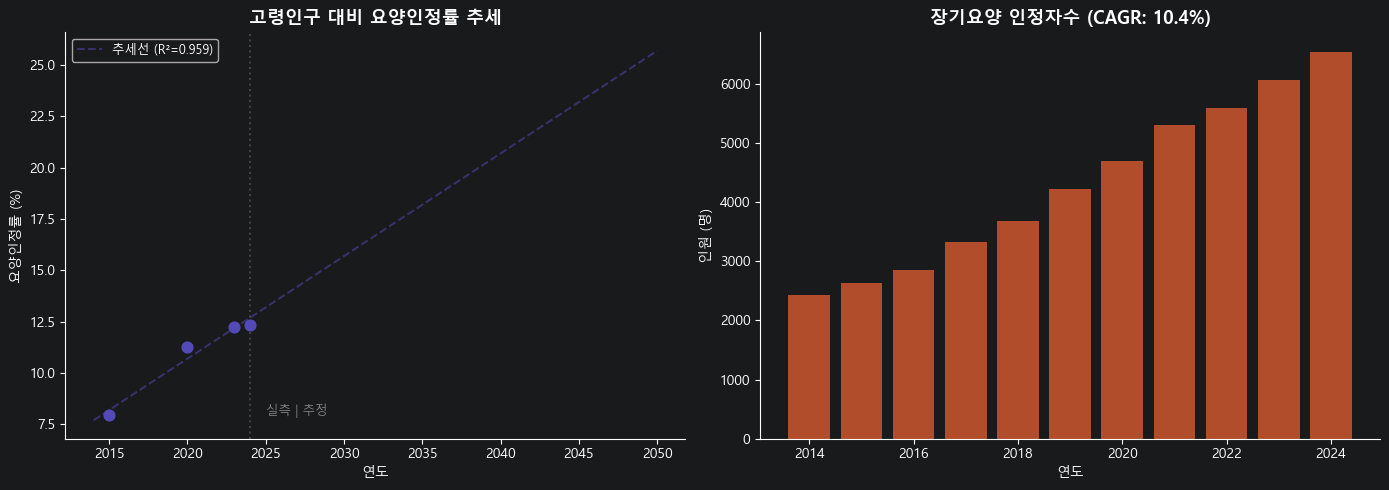

In [6]:
# ── 요양인정률 추세 시각화 ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 인정률 추세
ax1.scatter(x, y, color='#534AB7', s=60, zorder=3)
x_line = np.arange(2014, 2051)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, '--', color='#534AB7', alpha=0.5, label=f'추세선 (R²={r_value**2:.3f})')
ax1.axvline(x=2024, color='gray', ls=':', alpha=0.4)
ax1.text(2025, y.min(), '실측 | 추정', fontsize=9, color='gray')
ax1.set_xlabel('연도')
ax1.set_ylabel('요양인정률 (%)')
ax1.set_title('고령인구 대비 요양인정률 추세', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# 우: 절대 인원 추이
ax2.bar(mb_ltc['연도'], mb_ltc['요양_계'], color='#D85A30', alpha=0.8)
# 연평균 증가율
cagr = ((mb_ltc['요양_계'].iloc[-1] / mb_ltc['요양_계'].iloc[0]) ** (1/(len(mb_ltc)-1)) - 1) * 100
ax2.set_title(f'장기요양 인정자수 (CAGR: {cagr:.1f}%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('연도')
ax2.set_ylabel('인원 (명)')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FORECAST_DIR / '1_인정률_추세.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 아산시 고령인구 추계

충남 장래인구추계에서 아산시 비중을 적용하여 아산시 고령인구를 추정합니다.

In [7]:
# ── 아산시 / 충남 비중 산출 ──
# 실측 데이터에서 비중 확인
ratio_data = mb_valid[['연도', '총인구', '고령인구']].merge(
    mc[['연도', '총인구_추계', '고령인구_추계']],
    on='연도', how='inner'
)
ratio_data['총인구_비중'] = (ratio_data['총인구'] / ratio_data['총인구_추계'] * 100).round(2)
ratio_data['고령인구_비중'] = (ratio_data['고령인구'] / ratio_data['고령인구_추계'] * 100).round(2)

print('=== 아산시 / 충남 비중 ===')
print(ratio_data[['연도', '총인구_비중', '고령인구_비중']].to_string(index=False))

# 비중 추세 (선형)
x_r = ratio_data['연도'].values
y_r = ratio_data['고령인구_비중'].values
slope_r, intercept_r, _, _, _ = stats.linregress(x_r, y_r)
print(f'\n고령인구 비중 추세: {slope_r:.4f}%p/년 (최근: {y_r[-1]:.2f}%)')

=== 아산시 / 충남 비중 ===
  연도  총인구_비중  고령인구_비중
2015   15.21    10.09
2020   15.64    10.70
2023   17.09    11.28
2024   17.65    11.51

고령인구 비중 추세: 0.1559%p/년 (최근: 11.51%)


In [8]:
# ── 아산시 고령인구 추계 (3개 시나리오) ──
future_years = mc[mc['연도'] >= 2025][['연도', '총인구_추계', '고령인구_추계']].copy()

# 시나리오별 비중
latest_ratio = y_r[-1]  # 최신 실측 비중
trend_ratios = slope_r * future_years['연도'].values + intercept_r  # 추세 비중

# 시나리오 1: 현재 비중 유지 (보수적)
future_years['아산_고령_보수'] = (future_years['고령인구_추계'] * latest_ratio / 100).round(0).astype(int)

# 시나리오 2: 추세 비중 적용 (기본)
future_years['아산_비중_추세'] = np.clip(trend_ratios, latest_ratio * 0.8, latest_ratio * 1.5)  # 상하한 제한
future_years['아산_고령_기본'] = (future_years['고령인구_추계'] * future_years['아산_비중_추세'] / 100).round(0).astype(int)

# 시나리오 3: 비중 10% 상향 (적극적 — 아산시 인구 유입 가정)
future_years['아산_고령_적극'] = (future_years['고령인구_추계'] * latest_ratio * 1.1 / 100).round(0).astype(int)

print('=== 아산시 고령인구 추계 (주요 시점) ===')
future_years[future_years['연도'].isin([2025, 2030, 2035, 2040, 2045, 2050])][[
    '연도', '고령인구_추계', '아산_고령_보수', '아산_고령_기본', '아산_고령_적극'
]]

=== 아산시 고령인구 추계 (주요 시점) ===


,연도,고령인구_추계,아산_고령_보수,아산_고령_기본,아산_고령_적극
11,2025,486458,55991,56413,61590
16,2030,602247,69319,74535,76250
21,2035,710994,81835,93537,90019
26,2040,819216,94292,114161,103721
31,2045,893141,102801,131426,113081
36,2050,948457,109167,146960,120084


---
## 3. 등급별 수요 추정

아산시 추계 고령인구 × 요양인정률 트렌드 → 등급별 예상 인원

In [9]:
# ── 등급별 비중 (최근 3년 평균) ──
recent = mb_ltc.tail(3)

grade_main = ['요양_1등급', '요양_2등급', '요양_3등급', '요양_4등급', '요양_5등급']
grade_etc = ['요양_등급외', '요양_인지지원등급']
grade_all = [c for c in grade_main + grade_etc if c in recent.columns]

# 전체 대비 등급별 비중
grade_ratios = {}
for col in grade_all:
    ratio = (recent[col].fillna(0) / recent['요양_계']).mean()
    grade_ratios[col.replace('요양_', '')] = round(ratio, 4)

print('=== 등급별 비중 (최근 3년 평균) ===')
for g, r in grade_ratios.items():
    print(f'  {g}: {r*100:.1f}%')

=== 등급별 비중 (최근 3년 평균) ===
  1등급: 4.0%
  2등급: 8.5%
  3등급: 23.6%
  4등급: 36.0%
  5등급: 13.4%
  등급외: 10.2%
  인지지원등급: 4.4%


In [10]:
# ── 연도별 수요 추정 (기본 시나리오) ──
forecast_years = [2025, 2026, 2027, 2028, 2029, 2030, 2035, 2040, 2045, 2050]

records = []
for year in forecast_years:
    row = future_years[future_years['연도'] == year]
    if len(row) == 0:
        continue
    
    elderly = row['아산_고령_기본'].values[0]
    
    # 해당 연도 인정률 (추세선)
    rate = slope * year + intercept
    total_care = int(elderly * rate / 100)
    
    rec = {'연도': year, '추계_고령인구': elderly, '추정_인정률': round(rate, 2), '추정_요양인원': total_care}
    
    # 등급별 분배
    for grade, ratio in grade_ratios.items():
        rec[f'추정_{grade}'] = int(total_care * ratio)
    
    records.append(rec)

df_forecast = pd.DataFrame(records)

print('=== 등급별 수요 추정 (기본 시나리오) ===')
df_forecast

=== 등급별 수요 추정 (기본 시나리오) ===


,연도,추계_고령인구,추정_인정률,추정_요양인원,추정_1등급,추정_2등급,추정_3등급,추정_4등급,추정_5등급,추정_등급외,추정_인지지원등급
0,2025,56413,13.19,7440,299,630,1755,2675,994,760,324
1,2026,60518,13.69,8284,333,702,1954,2978,1107,846,361
2,2027,63924,14.19,9069,365,769,2139,3261,1212,926,395
3,2028,67607,14.69,9930,400,842,2342,3570,1327,1014,432
4,2029,70632,15.19,10727,432,909,2530,3857,1434,1096,467
5,2030,74535,15.69,11693,471,991,2758,4204,1563,1195,509
6,2035,93537,18.19,17011,685,1442,4012,6117,2274,1738,741
7,2040,114161,20.69,23615,951,2002,5570,8491,3157,2413,1029
8,2045,131426,23.19,30471,1227,2583,7188,10957,4073,3114,1328
9,2050,146960,25.68,37745,1521,3200,8904,13573,5046,3857,1645


In [11]:
# ── 3개 시나리오 비교 ──
scenarios = []
for year in forecast_years:
    row = future_years[future_years['연도'] == year]
    if len(row) == 0:
        continue
    
    rate = slope * year + intercept
    
    scenarios.append({
        '연도': year,
        '인정률': round(rate, 2),
        '보수_고령인구': row['아산_고령_보수'].values[0],
        '보수_요양인원': int(row['아산_고령_보수'].values[0] * rate / 100),
        '기본_고령인구': row['아산_고령_기본'].values[0],
        '기본_요양인원': int(row['아산_고령_기본'].values[0] * rate / 100),
        '적극_고령인구': row['아산_고령_적극'].values[0],
        '적극_요양인원': int(row['아산_고령_적극'].values[0] * rate / 100),
    })

df_scenarios = pd.DataFrame(scenarios)
print('=== 시나리오별 비교 ===')
df_scenarios

=== 시나리오별 비교 ===


,연도,인정률,보수_고령인구,보수_요양인원,기본_고령인구,기본_요양인원,적극_고령인구,적극_요양인원
0,2025,13.19,55991,7384,56413,7440,61590,8123
1,2026,13.69,59269,8113,60518,8284,65196,8924
2,2027,14.19,61785,8766,63924,9069,67963,9643
3,2028,14.69,64500,9474,67607,9930,70950,10421
4,2029,15.19,66527,10104,70632,10727,73180,11114
5,2030,15.69,69319,10874,74535,11693,76250,11962
6,2035,18.19,81835,14883,93537,17011,90019,16371
7,2040,20.69,94292,19505,114161,23615,103721,21455
8,2045,23.19,102801,23834,131426,30471,113081,26217
9,2050,25.68,109167,28038,146960,37745,120084,30842


---
## 4. 시설 소요량 추정

추정 수요 인원을 시설 유형별 기준 수용력으로 나누어 필요 시설수를 산출합니다.

In [12]:
# ── 시설 유형별 수용 기준 ──
# 일반적인 재가노인복지시설 기준 (조정 가능)
capacity = {
    '방문요양': 30,       # 요양보호사 1인당 약 3~4명, 시설당 약 8~10명 운영 → 30명/시설
    '방문목욕': 50,       # 차량 기반, 넓은 커버리지
    '방문간호': 40,       # 간호사 기반
    '주야간보호': 20,     # 정원 기반 (통상 15~25명)
    '복지용구': 200,      # 대여/판매 기반
    '재가노인지원서비스': 100,  # 상담/연계 중심
}

# 등급별 주요 이용 서비스 매핑
# 1-2등급: 주야간보호 + 방문요양 집중
# 3-4등급: 방문요양 중심
# 5등급/인지지원: 주야간보호 + 방문요양 경량
service_need = {
    '방문요양': 0.50,     # 전체 인원의 50%가 방문요양 이용
    '방문목욕': 0.25,
    '주야간보호': 0.20,
    '방문간호': 0.10,
    '복지용구': 0.05,
    '재가노인지원서비스': 0.03,
}

print('시설 유형별 수용 기준 (명/시설):')
for k, v in capacity.items():
    print(f'  {k}: {v}명')

시설 유형별 수용 기준 (명/시설):
  방문요양: 30명
  방문목욕: 50명
  방문간호: 40명
  주야간보호: 20명
  복지용구: 200명
  재가노인지원서비스: 100명


In [13]:
# ── 시설 소요량 산출 ──
key_years = [2025, 2030, 2035, 2040, 2045, 2050]
df_key = df_forecast[df_forecast['연도'].isin(key_years)].copy()

facility_needs = []
for _, row in df_key.iterrows():
    year = row['연도']
    total = row['추정_요양인원']
    
    rec = {'연도': year, '추정_요양인원': total}
    for svc, need_ratio in service_need.items():
        demand_count = int(total * need_ratio)
        cap = capacity[svc]
        needed = int(np.ceil(demand_count / cap))
        rec[f'{svc}_이용수요'] = demand_count
        rec[f'{svc}_필요시설'] = needed
    
    facility_needs.append(rec)

df_facility_need = pd.DataFrame(facility_needs)

# 필요 시설수만 추출
need_cols = ['연도', '추정_요양인원'] + [c for c in df_facility_need.columns if '필요시설' in c]
print('=== 연도별 필요 시설수 ===')
df_facility_need[need_cols]

=== 연도별 필요 시설수 ===


,연도,추정_요양인원,방문요양_필요시설,방문목욕_필요시설,주야간보호_필요시설,방문간호_필요시설,복지용구_필요시설,재가노인지원서비스_필요시설
0,2025.0,7440.0,124,38,75,19,2,3
1,2030.0,11693.0,195,59,117,30,3,4
2,2035.0,17011.0,284,86,171,43,5,6
3,2040.0,23615.0,394,119,237,60,6,8
4,2045.0,30471.0,508,153,305,77,8,10
5,2050.0,37745.0,630,189,378,95,10,12


In [14]:
# ── 현재 시설 vs 필요 시설 비교 ──
from pathlib import Path

PRE_DIR = DATA_DIR.parent / 'preprocessed'
df_fac_now = pd.read_csv(PRE_DIR / '05_재가노인복지시설_아산.csv', encoding='cp949')

current = df_fac_now['종류'].value_counts().to_dict()

# 2030년 기준 갭
row_2030 = df_facility_need[df_facility_need['연도'] == 2030].iloc[0]
row_2040 = df_facility_need[df_facility_need['연도'] == 2040].iloc[0]

gap_records = []
for svc in capacity.keys():
    now = current.get(svc, 0)
    need_30 = row_2030[f'{svc}_필요시설']
    need_40 = row_2040[f'{svc}_필요시설']
    gap_records.append({
        '시설유형': svc,
        '현재(2024)': now,
        '필요(2030)': need_30,
        '부족(2030)': max(0, need_30 - now),
        '필요(2040)': need_40,
        '부족(2040)': max(0, need_40 - now),
    })

df_gap = pd.DataFrame(gap_records)
print('=== 시설 유형별 현재 vs 필요 ===')
df_gap

=== 시설 유형별 현재 vs 필요 ===


,시설유형,현재(2024),필요(2030),부족(2030),필요(2040),부족(2040)
0,방문요양,36,195.0,159.0,394.0,358.0
1,방문목욕,20,59.0,39.0,119.0,99.0
2,방문간호,3,30.0,27.0,60.0,57.0
3,주야간보호,20,117.0,97.0,237.0,217.0
4,복지용구,1,3.0,2.0,6.0,5.0
5,재가노인지원서비스,4,4.0,0.0,8.0,4.0


---
## 5. 수요 예측 시각화

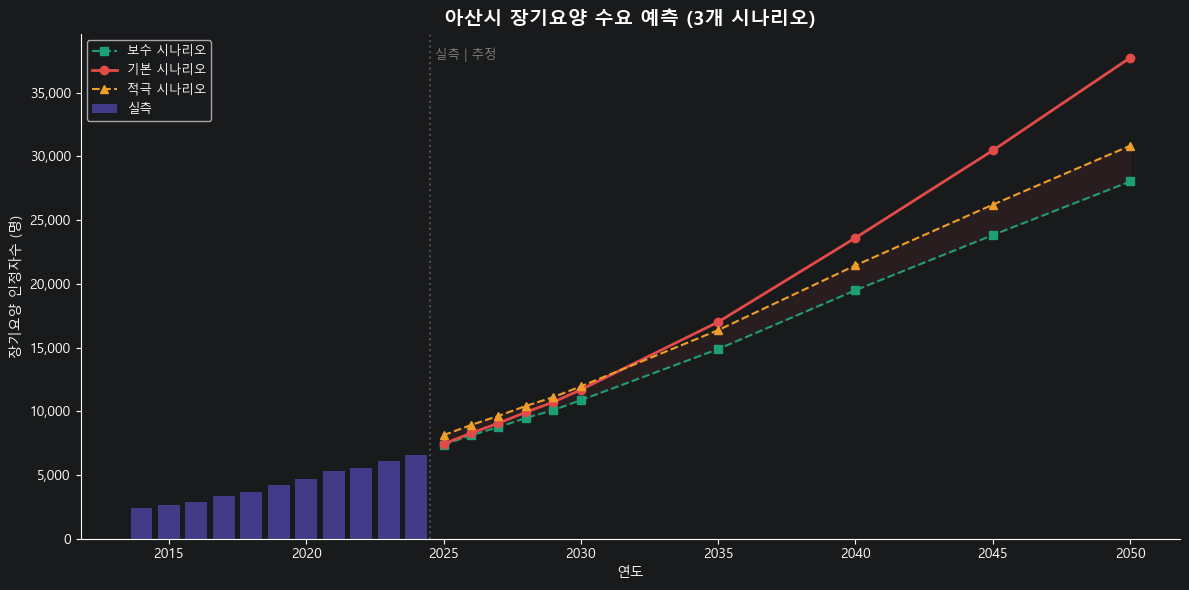

In [15]:
# ── 5-1. 수요 추정 시나리오 비교 ──
fig, ax = plt.subplots(figsize=(12, 6))

# 실측
mb_hist = mb.dropna(subset=['요양_계'])
ax.bar(mb_hist['연도'], mb_hist['요양_계'], color='#534AB7', alpha=0.7, width=0.8, label='실측')

# 시나리오
ax.plot(df_scenarios['연도'], df_scenarios['보수_요양인원'], 's--', color='#1D9E75', lw=1.5, label='보수 시나리오')
ax.plot(df_scenarios['연도'], df_scenarios['기본_요양인원'], 'o-', color='#E24B4A', lw=2, label='기본 시나리오')
ax.plot(df_scenarios['연도'], df_scenarios['적극_요양인원'], '^--', color='#EF9F27', lw=1.5, label='적극 시나리오')

# 시나리오 범위 음영
ax.fill_between(df_scenarios['연도'], df_scenarios['보수_요양인원'],
                df_scenarios['적극_요양인원'], alpha=0.08, color='#E24B4A')

ax.axvline(x=2024.5, color='gray', ls=':', alpha=0.5)
ax.text(2024.7, ax.get_ylim()[1] * 0.95, '실측 | 추정', fontsize=9, color='gray')

ax.set_xlabel('연도')
ax.set_ylabel('장기요양 인정자수 (명)')
ax.set_title('아산시 장기요양 수요 예측 (3개 시나리오)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FORECAST_DIR / '5_1_수요예측_시나리오.png', dpi=150, bbox_inches='tight')
plt.show()

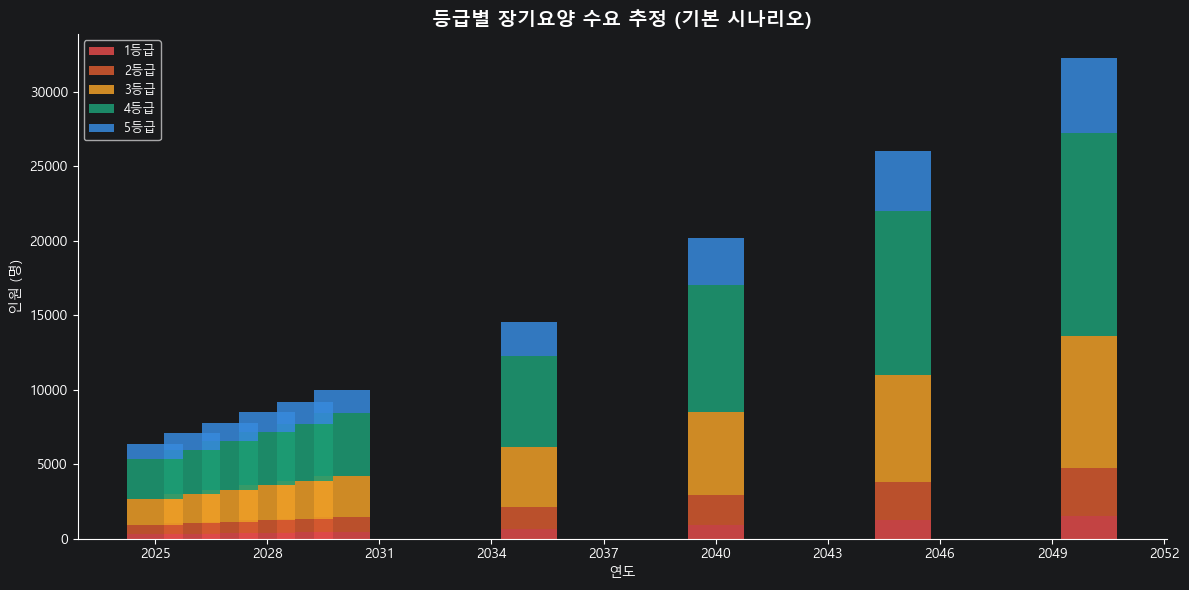

In [16]:
# ── 5-2. 등급별 수요 추이 (기본 시나리오) ──
fig, ax = plt.subplots(figsize=(12, 6))

grade_forecast_cols = [c for c in df_forecast.columns if c.startswith('추정_') and '등급' in c]
colors = ['#E24B4A', '#D85A30', '#EF9F27', '#1D9E75', '#378ADD']

bottom = np.zeros(len(df_forecast))
for col, color in zip(grade_forecast_cols[:5], colors):
    label = col.replace('추정_', '')
    vals = df_forecast[col].fillna(0).values
    ax.bar(df_forecast['연도'], vals, bottom=bottom, color=color, alpha=0.85, label=label, width=1.5)
    bottom += vals

ax.set_xlabel('연도')
ax.set_ylabel('인원 (명)')
ax.set_title('등급별 장기요양 수요 추정 (기본 시나리오)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FORECAST_DIR / '5_2_등급별_수요추정.png', dpi=150, bbox_inches='tight')
plt.show()

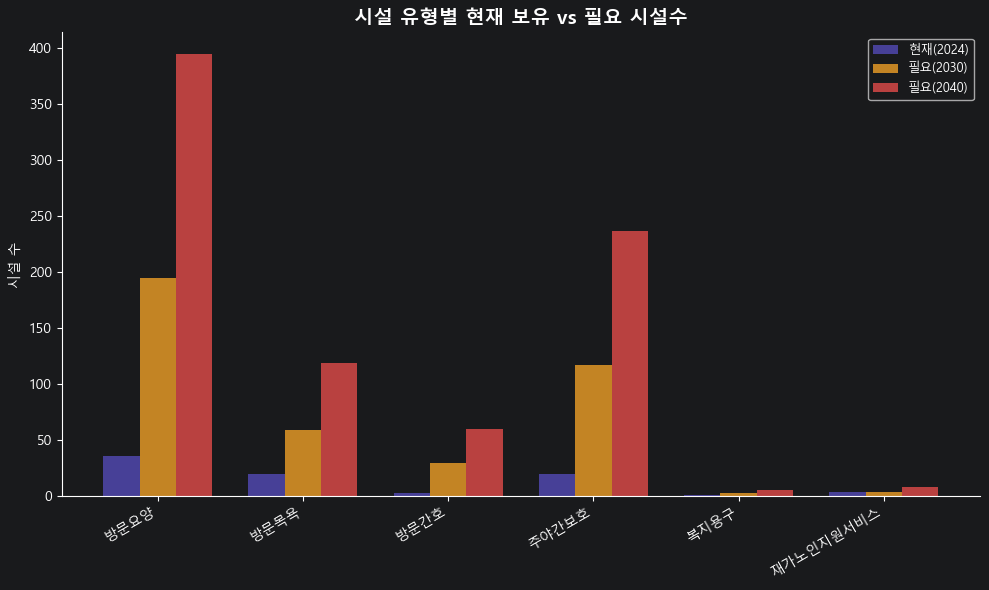

In [17]:
# ── 5-3. 시설 부족량 시각화 ──
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(df_gap))
w = 0.25

ax.bar(x_pos - w, df_gap['현재(2024)'], w, label='현재(2024)', color='#534AB7', alpha=0.8)
ax.bar(x_pos, df_gap['필요(2030)'], w, label='필요(2030)', color='#EF9F27', alpha=0.8)
ax.bar(x_pos + w, df_gap['필요(2040)'], w, label='필요(2040)', color='#E24B4A', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_gap['시설유형'], rotation=30, ha='right')
ax.set_ylabel('시설 수')
ax.set_title('시설 유형별 현재 보유 vs 필요 시설수', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FORECAST_DIR / '5_3_시설부족량.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. 예측 결과 저장

In [18]:
# ── 저장 ──
df_forecast.to_csv(FORECAST_DIR / 'forecast_등급별_수요추정.csv', index=False, encoding='cp949')
df_scenarios.to_csv(FORECAST_DIR / 'forecast_시나리오_비교.csv', index=False, encoding='cp949')
df_facility_need.to_csv(FORECAST_DIR / 'forecast_시설소요량.csv', index=False, encoding='cp949')
df_gap.to_csv(FORECAST_DIR / 'forecast_시설부족_현재vs필요.csv', index=False, encoding='cp949')
future_years.to_csv(FORECAST_DIR / 'forecast_아산시_고령인구_추계.csv', index=False, encoding='cp949')

print('저장 완료:')
print('  forecast_등급별_수요추정.csv')
print('  forecast_시나리오_비교.csv')
print('  forecast_시설소요량.csv')
print('  forecast_시설부족_현재vs필요.csv')
print('  forecast_아산시_고령인구_추계.csv')
print(f'  차트 3개 (.png)')
print(f'\n저장 경로: {FORECAST_DIR}')

저장 완료:
  forecast_등급별_수요추정.csv
  forecast_시나리오_비교.csv
  forecast_시설소요량.csv
  forecast_시설부족_현재vs필요.csv
  forecast_아산시_고령인구_추계.csv
  차트 3개 (.png)

저장 경로: C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\forecast
